# 12. Exploratory Analysis & Linear Regression


## 12.1 Load ML Features Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

feature_dataset_path = r"A:\pc\Desktop\Code\data science\sadop\Data\ml_features.csv"
df = pd.read_csv(feature_dataset_path)
print("Shape:", df.shape)
df.head()

Shape: (19975, 15)


,query,query_time,rows_returned,has_sum,has_group_by,has_where,tables_count,query_length,cpu_usage,estimated_rows,uses_index,full_table_scan,uses_filesort,uses_temp_table,is_slow
0,SELECT *\nFROM user\nWHERE user_id IN (\n S...,0.850983,16520,0,0,1,1,189,25.0,54923,1,1,0,0,1
1,"SELECT u.user_id,\n (\n SELECT S...",0.745494,20000,1,0,1,2,217,0.0,20207,1,0,0,0,1
2,SELECT *\nFROM user u\nWHERE EXISTS (\n SEL...,0.574111,16121,0,0,1,2,184,0.0,54923,1,1,0,0,0
3,"SELECT u.user_id, t.transaction_date, t.amount...",1.684971,250000,0,0,0,3,185,0.0,34725,1,0,1,1,1
4,"SELECT u.user_id,\n (\n SELECT S...",0.599545,20000,1,0,1,2,217,0.0,20207,1,0,0,0,0


## 12.2 Quick Summary Statistics


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
query_time,19975.0,0.878726,1.517166,0.0,0.086555,0.495865,0.719669,9.993443
rows_returned,19975.0,42029.306783,75354.039549,0.0,2669.000000,16520.000000,20000.000000,250000.000000
has_sum,19975.0,0.250513,0.433319,0.0,0.000000,0.000000,1.000000,1.000000
has_group_by,19975.0,0.371464,0.483208,0.0,0.000000,0.000000,1.000000,1.000000
has_where,19975.0,0.561752,0.496184,0.0,0.000000,1.000000,1.000000,1.000000
tables_count,19975.0,2.247209,0.896666,1.0,2.000000,2.000000,3.000000,4.000000
query_length,19975.0,159.240551,53.536735,47.0,151.000000,183.000000,198.000000,227.000000
cpu_usage,19975.0,8.006894,16.997823,0.0,0.000000,0.000000,12.500000,100.000000
estimated_rows,19975.0,132055.045457,118991.382014,9.0,34724.000000,54915.000000,249887.000000,295636.000000
uses_index,19975.0,0.878098,0.327181,0.0,1.000000,1.000000,1.000000,1.000000


## 2.3 cheking messing values



In [3]:
print("Missing values:")
print(df.isna().sum())

# Fix estimated_rows NaN → 0
df["estimated_rows"] = df["estimated_rows"].fillna(0)
print("\nAfter fix:")
print(df.isna().sum())


Missing values:
query              0
query_time         0
rows_returned      0
has_sum            0
has_group_by       0
has_where          0
tables_count       0
query_length       0
cpu_usage          0
estimated_rows     0
uses_index         0
full_table_scan    0
uses_filesort      0
uses_temp_table    0
is_slow            0
dtype: int64

After fix:
query              0
query_time         0
rows_returned      0
has_sum            0
has_group_by       0
has_where          0
tables_count       0
query_length       0
cpu_usage          0
estimated_rows     0
uses_index         0
full_table_scan    0
uses_filesort      0
uses_temp_table    0
is_slow            0
dtype: int64


## 2.4 Visualize Query Time Distributions


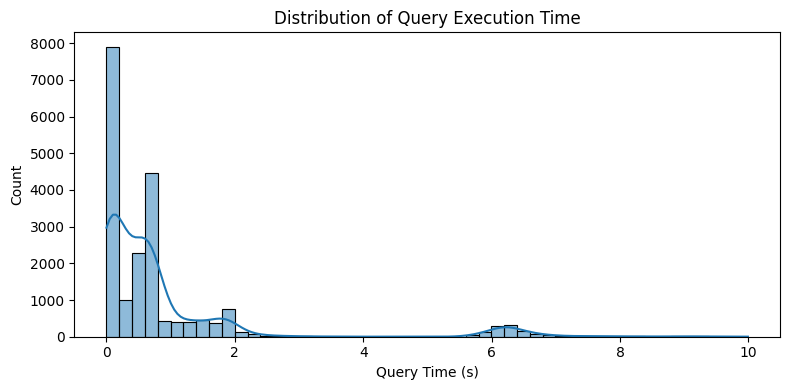

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['query_time'], bins=50, kde=True)
plt.title('Distribution of Query Execution Time')
plt.xlabel('Query Time (s)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## 2.5 Log-Scale Visualization

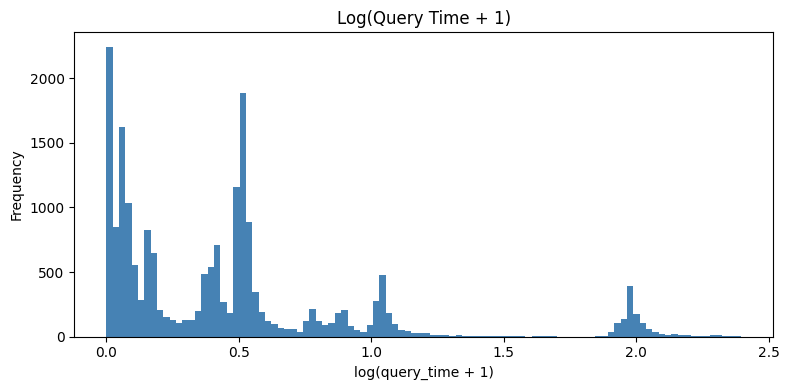

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(df["query_time"]), bins=100, color="steelblue")
plt.title("Log(Query Time + 1)")
plt.xlabel("log(query_time + 1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 2.6 Feature Distributions

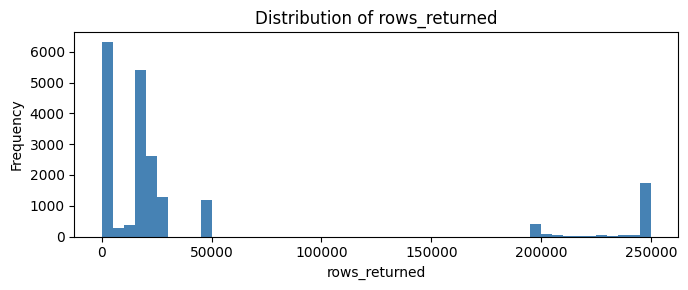

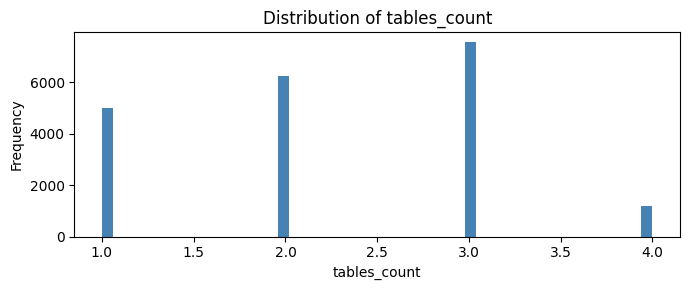

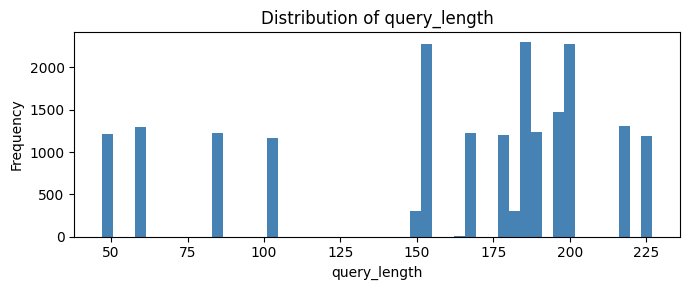

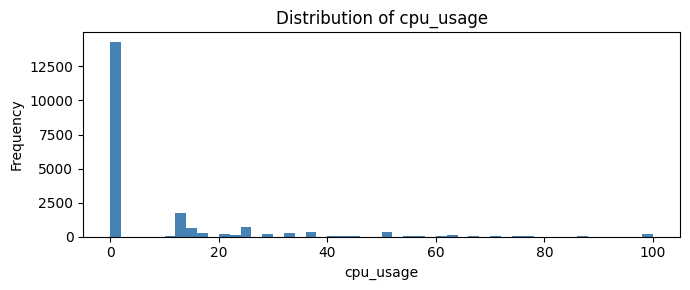

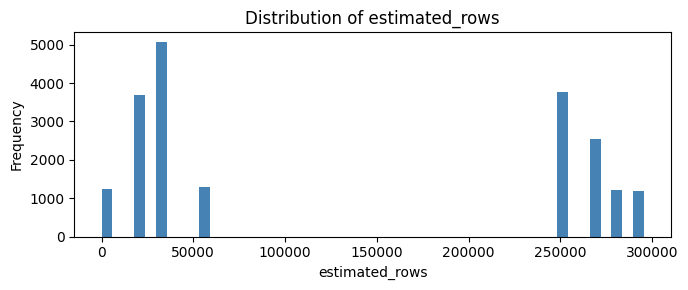

In [8]:
numeric_features = [
    "rows_returned",
    "tables_count",
    "query_length",
    "cpu_usage",
    "estimated_rows",
]

for col in numeric_features:
    plt.figure(figsize=(7, 3))
    plt.hist(df[col], bins=50, color="steelblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# 2.7 Binary EXPLAIN Feature Rates

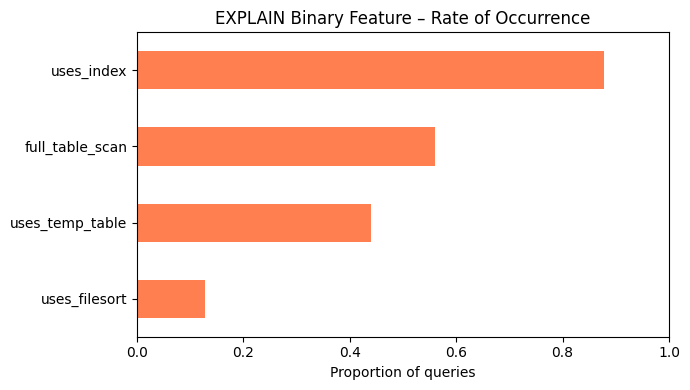

uses_filesort      0.128
uses_temp_table    0.441
full_table_scan    0.561
uses_index         0.878
dtype: float64


In [9]:
binary_explain = ["uses_index", "full_table_scan", "uses_filesort", "uses_temp_table"]

rates = df[binary_explain].mean().sort_values()
plt.figure(figsize=(7, 4))
rates.plot(kind="barh", color="coral")
plt.title("EXPLAIN Binary Feature – Rate of Occurrence")
plt.xlabel("Proportion of queries")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(rates.round(3))


## 2.8 Correlation Matrix & Analysis

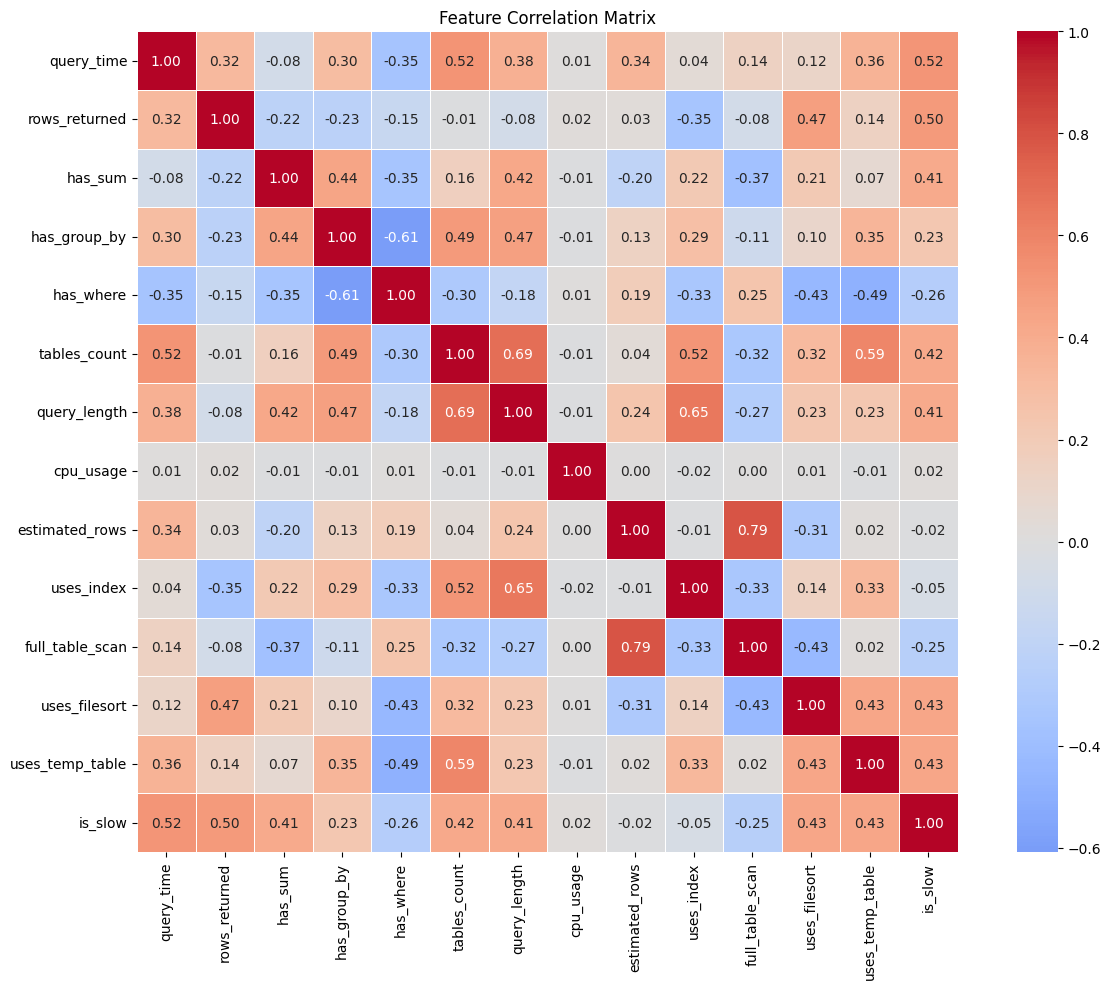

In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 2.6 Train / Test Split

In [12]:
from sklearn.model_selection import train_test_split

FEATURE_COLUMNS = [
    # original
    "rows_returned", "tables_count", "query_length",
    "has_sum", "has_group_by", "has_where",
    "cpu_usage",
    # EXPLAIN
    "estimated_rows", "uses_index", "full_table_scan",
    "uses_filesort", "uses_temp_table",
]

X = df[FEATURE_COLUMNS]
y = df["is_slow"]   # classification target  (0 = fast, 1 = slow)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")
print(f"\nClass balance in train:\n{y_train.value_counts(normalize=True).round(3)}")



Train size : 15,980
Test  size : 3,995

Class balance in train:
is_slow
0    0.561
1    0.439
Name: proportion, dtype: float64


# 2.7 Random Forest Training

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",   
    random_state=42,
    n_jobs=-1                  
)

rf.fit(X_train, y_train)
print("✅ Random Forest trained")

✅ Random Forest trained


# 2.8 Evaluation

Classification Report:
              precision    recall  f1-score   support

        Fast       0.98      0.99      0.99      2240
        Slow       0.99      0.97      0.98      1755

    accuracy                           0.98      3995
   macro avg       0.99      0.98      0.98      3995
weighted avg       0.98      0.98      0.98      3995

ROC-AUC : 0.9975


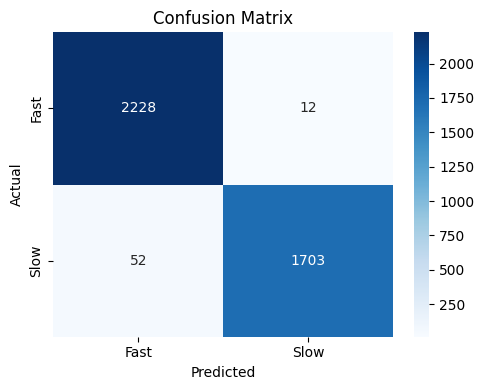

<Figure size 600x500 with 0 Axes>

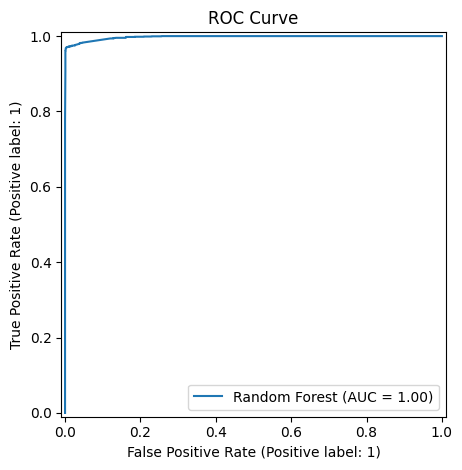

In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)

y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Fast", "Slow"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_prob):.4f}")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fast", "Slow"],
            yticklabels=["Fast", "Slow"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# 2.9  Feature Importance

C:\Users\pc\AppData\Local\Temp\ipykernel_37020\1466189269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")


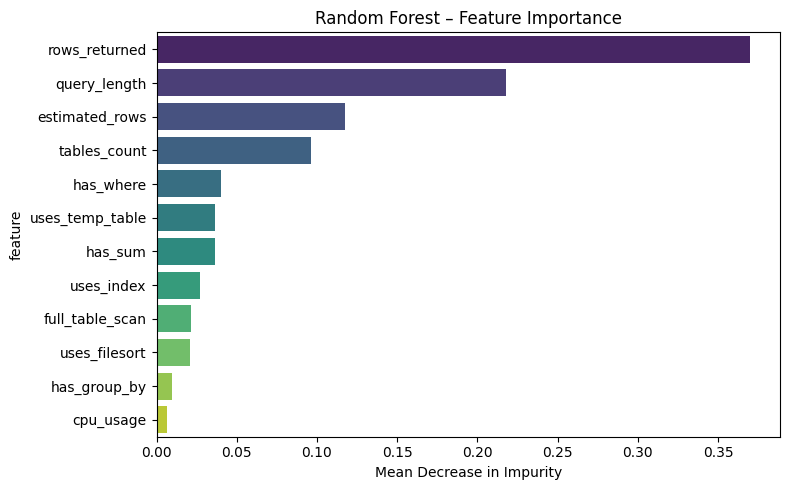

        feature  importance
  rows_returned    0.370161
   query_length    0.217672
 estimated_rows    0.117319
   tables_count    0.096583
      has_where    0.040501
uses_temp_table    0.036355
        has_sum    0.036256
     uses_index    0.027049
full_table_scan    0.021282
  uses_filesort    0.020944
   has_group_by    0.009343
      cpu_usage    0.006536


In [17]:
importance_df = pd.DataFrame({
    "feature":    FEATURE_COLUMNS,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Random Forest – Feature Importance")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))